In [1]:
import os

os.environ["TQDM_DISABLE"] = "True"
os.environ["TQDM_MININTERVAL"] = "10"

In [2]:
import tree_comparison.tree_compare as tc
from joblib import Memory
from itertools import combinations
from glob import glob

In [3]:
import pandas as pd
import json
import numpy as np

from neuron_morphology.constants import AXON, BASAL_DENDRITE, APICAL_DENDRITE, SOMA
from neuron_morphology.morphology import Morphology
def load_morphology(swc_file):
    # check if json or swc
    if swc_file.endswith('.json'):
        # Load the morphology from a JSON file
        with open(swc_file, 'r') as f:
            data = json.load(f)
        neuron = data["neurons"][0]
        dendrites = pd.DataFrame(neuron["dendrite"]).replace(-1, 0).assign(type=BASAL_DENDRITE)
        soma = neuron["soma"]
        soma["sampleNumber"] = 0
        soma["parentNumber"] = -1
        columns = {
            "sampleNumber": "id",
            "parentNumber": "parent",
        }
        soma = pd.DataFrame([soma]).assign(type=SOMA)
        df = pd.concat([soma, dendrites])
        # mirror images of R hemisphere cells
        df["z"] = df["z"].apply(lambda x: np.minimum(x, 11400-x))
        records = df.rename(columns=columns).to_dict(orient="records")

        return Morphology(records, node_id_cb=lambda node: node["id"], parent_id_cb=lambda node: node["parent"]), soma
    elif swc_file.endswith('.swc'):
        # Load the morphology from a SWC file
        return morphology_from_swc(swc_file)
    else:
        raise ValueError("Unsupported file format. Please provide a SWC or JSON file.")


# from neuron_morphology.swc_io import morphology_from_swc
# # monkey patch this function to use load_morphology
# morphology_from_swc = load_morphology

In [4]:
morphos = {}
records = []

files = glob("/data/*/Complete_annotated/*.json")[:]
for file in files:
    try:
        morphos[file], soma = load_morphology(file)
        soma["file"] = file
        records.append(soma)
    except KeyError as e:
        pass

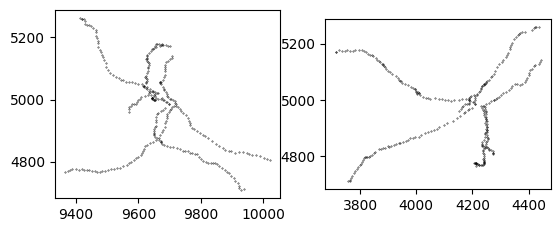

In [5]:
import neuron_morphology.vis.morphovis as mv 
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(1,2)
mv.plot_morphology_xy(morphos[files[0]], ax=ax[0])
mv.plot_morphology_zy(morphos[files[0]], ax=ax[1])

## Soma info

In [6]:
soma_df = pd.concat(records)
soma_df.head()

,x,y,z,allenId,sampleNumber,parentNumber,type,file
0,9697.7129,4986.8796,7189.7776,146,0,-1,1,/data/648434_12_5_24/Complete_annotated/N012-6...
0,10547.6826,4832.4666,4863.8392,771,0,-1,1,/data/648434_12_5_24/Complete_annotated/N022-6...
0,9805.1909,5907.0996,4330.8163,658,0,-1,1,/data/648434_12_5_24/Complete_annotated/N026-6...
0,10728.7251,4441.3044,4679.5984,771,0,-1,1,/data/648434_12_5_24/Complete_annotated/N023-6...
0,10184.9323,4583.9386,4759.3966,771,0,-1,1,/data/648434_12_5_24/Complete_annotated/N020-6...


In [7]:

soma_df["subject"] = [x.split("/")[2].split("_")[0] for x in soma_df["file"]]
soma_df = soma_df.query("x>10000 and y<5500")
soma_df.shape

(104, 9)

(10011.240725, 11043.651775, 3690.5139249999997, 5293.450975)

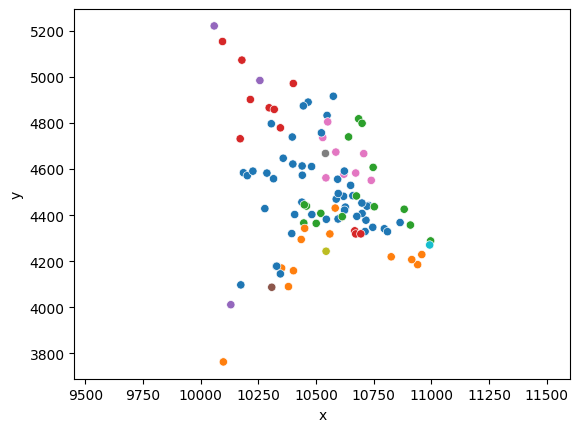

In [8]:
import seaborn as sns
sns.scatterplot(soma_df, x="x", y="y", hue="allenId", palette="tab10", legend=False)
plt.axis('equal')

(10011.240725, 11043.651775, 4497.22813, 7040.88947)

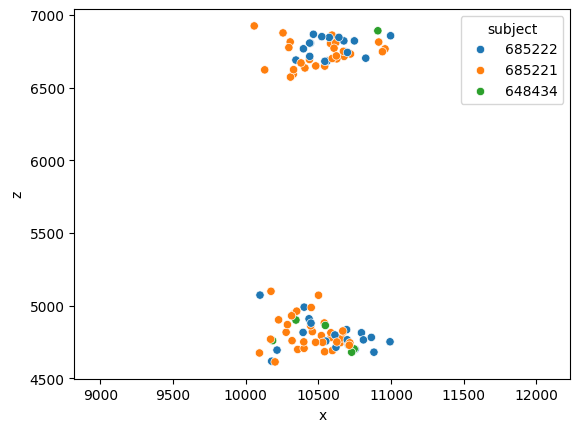

In [9]:
sns.scatterplot(soma_df.sample(frac=1), x="x", y="z", hue="subject", palette="tab10", legend=True)
plt.axis('equal')

## distances

In [10]:

memory = Memory("/scratch/cache", verbose=0)

@memory.cache
def compare(paths_tuple):
    """
    Compare two trees and return the result.
    """
    path1, path2 = paths_tuple  # Unpack the tuple of paths
    try:
        result = tc.compare_two_trees(
            path1, 
            path2, 
            simFunc="convex",
            maxDepth=1,
            orientation=0,
            compartments=[3],
            valid_set_dict="",
            partition_length=1/2000,
            angle_threshold=None, 
            segment_threshold=None,
        )
        distance, norm_distance = result[:2]
        return {
            "file1": path1,
            "file2": path2,
            "distance": distance,
            "norm_distance": norm_distance
        }
    except Exception as e:
        print(f"Error comparing {path1} and {path2}: {e}")
        return {
            "file1": path1,
            "file2": path2,
            "distance": None,
            "norm_distance": None
        }

In [11]:
# clear the cache
# memory.clear(warn=False)

In [ ]:
from joblib import Parallel, delayed

# files = glob("/data/*/Complete_annotated/*.json")[:]
pairs = list(combinations(soma_df["file"], 2))
records = []


# with Pool(processes=16) as pool:
#     results = list(
#         tqdm(pool.imap(compare, pairs), total=len(pairs), desc="Comparing trees", unit="pair")
#     )
print(f"Number of pairs: {len(pairs)}")
generator = Parallel(n_jobs=16, return_as="generator", verbose=10)(delayed(compare)(pair) for pair in pairs)
# results = list(tqdm(generator, desc="Comparing trees", unit="pair", total=len(pairs)))
results = list(generator)

# for i in trange(len(pairs), desc="Comparing trees", unit="pair"):
#     file1, file2 = pairs[i]
#     result = compare(file1, file2)
    


Number of pairs: 5356


[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    4.2s
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    4.2s
[Parallel(n_jobs=16)]: Done  29 tasks      | elapsed:    4.3s
[Parallel(n_jobs=16)]: Batch computation too fast (0.18216766380957364s.) Setting batch_size=2.
[Parallel(n_jobs=16)]: Done  40 tasks      | elapsed:    4.3s
[Parallel(n_jobs=16)]: Done  53 tasks      | elapsed:    4.3s
[Parallel(n_jobs=16)]: Done  66 tasks      | elapsed:    4.3s
[Parallel(n_jobs=16)]: Batch computation too fast (0.03963923454284668s.) Setting batch_size=4.
[Parallel(n_jobs=16)]: Done  92 tasks      | elapsed:    4.4s
[Parallel(n_jobs=16)]: Done 120 tasks      | elapsed:    4.4s
[Parallel(n_jobs=16)]: Batch computation too fast (0.07855677604675293s.) Setting batch_size=8.
[Parallel(n_jobs=16)]: Done 169 tasks      | elapsed:    4.5s
[Parallel(n_jobs=16)]: Done 228 tasks      | elapsed:    4.5s
[Parallel(n_job

In [ ]:
import pandas as pd
df = pd.DataFrame.from_records(results).dropna(how="any")
files = pd.concat([df["file1"], df["file2"]]).unique()
files.sort()
df.head()

,file1,file2,distance,norm_distance
0,/data/648434_12_5_24/Complete_annotated/N012-6...,/data/648434_12_5_24/Complete_annotated/N022-6...,7897.3484,0.8872
1,/data/648434_12_5_24/Complete_annotated/N012-6...,/data/648434_12_5_24/Complete_annotated/N026-6...,7535.7651,0.8429
2,/data/648434_12_5_24/Complete_annotated/N012-6...,/data/648434_12_5_24/Complete_annotated/N023-6...,4191.3647,0.7918
4,/data/648434_12_5_24/Complete_annotated/N012-6...,/data/648434_12_5_24/Complete_annotated/N020-6...,4526.6172,0.8024
5,/data/648434_12_5_24/Complete_annotated/N012-6...,/data/648434_12_5_24/Complete_annotated/N011-6...,5133.2886,0.8429


In [ ]:
# organize these distances into a matrix
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns



file_dict = {f: i for i, f in enumerate(files)}
n_files = len(files)
distance_matrix_np = np.zeros((n_files, n_files))
norm_distance_matrix_np = np.zeros((n_files, n_files))

for i, row in df.iterrows():
    file1 = row["file1"]
    file2 = row["file2"]
    distance = row["distance"]
    norm_distance = row["norm_distance"]
    distance_matrix_np[file_dict[file1], file_dict[file2]] = distance
    distance_matrix_np[file_dict[file2], file_dict[file1]] = distance
    norm_distance_matrix_np[file_dict[file1], file_dict[file2]] = norm_distance
    norm_distance_matrix_np[file_dict[file2], file_dict[file1]] = norm_distance
    

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import numpy as np

def set_size(w, h, ax=None):
    """ w, h: width, height in inches """
    if not ax: ax=plt.gca()
    l = ax.figure.subplotpars.left
    r = ax.figure.subplotpars.right
    t = ax.figure.subplotpars.top
    b = ax.figure.subplotpars.bottom
    figw = float(w)/(r-l)
    figh = float(h)/(t-b)
    ax.figure.set_size_inches(figw, figh)

def create_morphology_scatter_plot(embedding, morphology_dict, files, plot_fcn):
    # Create a large figure
    fig = plt.figure(figsize=(10, 10))
    main_ax = fig.add_subplot(111)
    
    # Hide axes and keep background
    main_ax.set_xticks([])
    main_ax.set_yticks([])
    
    # Calculate suitable size for the mini plots
    # points_spread = np.max(embedding, axis=0) - np.min(embedding, axis=0)
    # mini_size = min(points_spread) / 20000  # Reduced by a factor of 10 (was /15)
    
    # Normalize coordinates
    x_min, y_min = np.min(embedding, axis=0)
    x_max, y_max = np.max(embedding, axis=0)
    buffer = 0.05  # Buffer space around the edges (5%)
    x_range = x_max - x_min
    y_range = y_max - y_min
    main_ax.set_xlim(x_min - buffer*x_range, x_max + buffer*x_range)
    main_ax.set_ylim(y_min - buffer*y_range, y_max + buffer*y_range)
    
    # Plot each morphology at its embedding location
    for i, file in enumerate(files):
        # Create a small figure for this morphology
        mini_fig = plt.figure(figsize=(1, 1), dpi=100)
        mini_ax = mini_fig.add_subplot(111)
        
        # Plot the morphology using plot_morphology_zy
        plot_fcn(morphology_dict[file], ax=mini_ax)
        mini_ax.axis('off')
        mini_fig.tight_layout(pad=0)
        
        # Convert the mini figure to an image
        mini_fig.canvas.draw()
        image_from_plot = np.frombuffer(mini_fig.canvas.tostring_rgb(), dtype=np.uint8)
        image_from_plot = image_from_plot.reshape(mini_fig.canvas.get_width_height()[::-1] + (3,))
        plt.close(mini_fig)
        
        # Add the mini plot as an annotation at the embedding coordinates
        im = OffsetImage(image_from_plot, zoom=1/4)
        ab = AnnotationBbox(im, (embedding[i, 0], embedding[i, 1]), frameon=False)
        main_ax.add_artist(ab)
    
    # Add title
    # main_ax.set_title('Morphology Embedding with ZY Projections', fontsize=16)
    
    # Display the plot
    plt.tight_layout()
    return fig


## unnormalized MDS

In [ ]:
from sklearn import manifold

model = manifold.MDS(n_components=2, dissimilarity="precomputed")

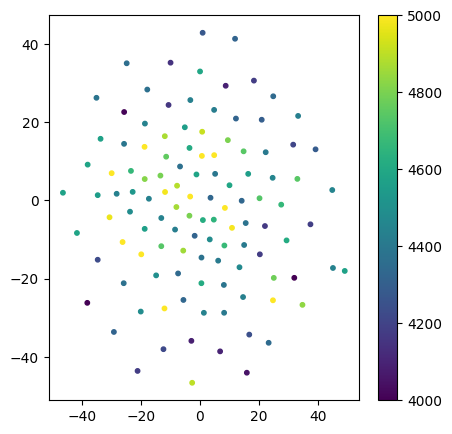

In [ ]:
embedding = model.fit_transform(distance_matrix_np)

plt.figure(figsize=(5, 5))
plt.scatter(embedding[:, 0], embedding[:, 1], s=10, c=soma_df["y"])
clim=(4000, 5000)
# set colorbar limits
plt.clim(clim)
plt.colorbar()

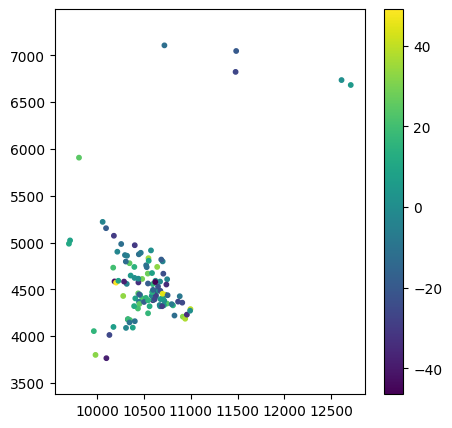

In [ ]:
embedding = model.fit_transform(distance_matrix_np)

plt.figure(figsize=(5, 5))
plt.scatter(soma_df["x"], soma_df["y"], c=embedding[:, 0], s=10)
plt.axis('equal')
plt.colorbar()

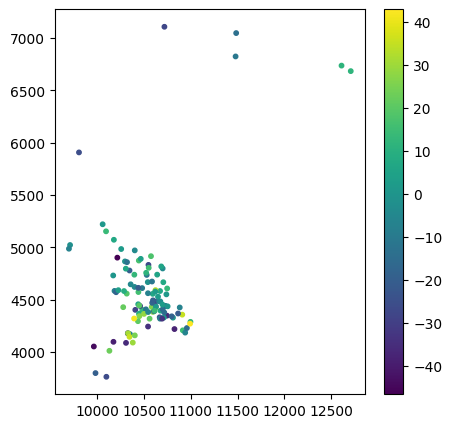

In [ ]:
embedding = model.fit_transform(distance_matrix_np)

plt.figure(figsize=(5, 5))
plt.scatter(soma_df["x"], soma_df["y"], c=embedding[:, 1], s=10)
plt.colorbar()

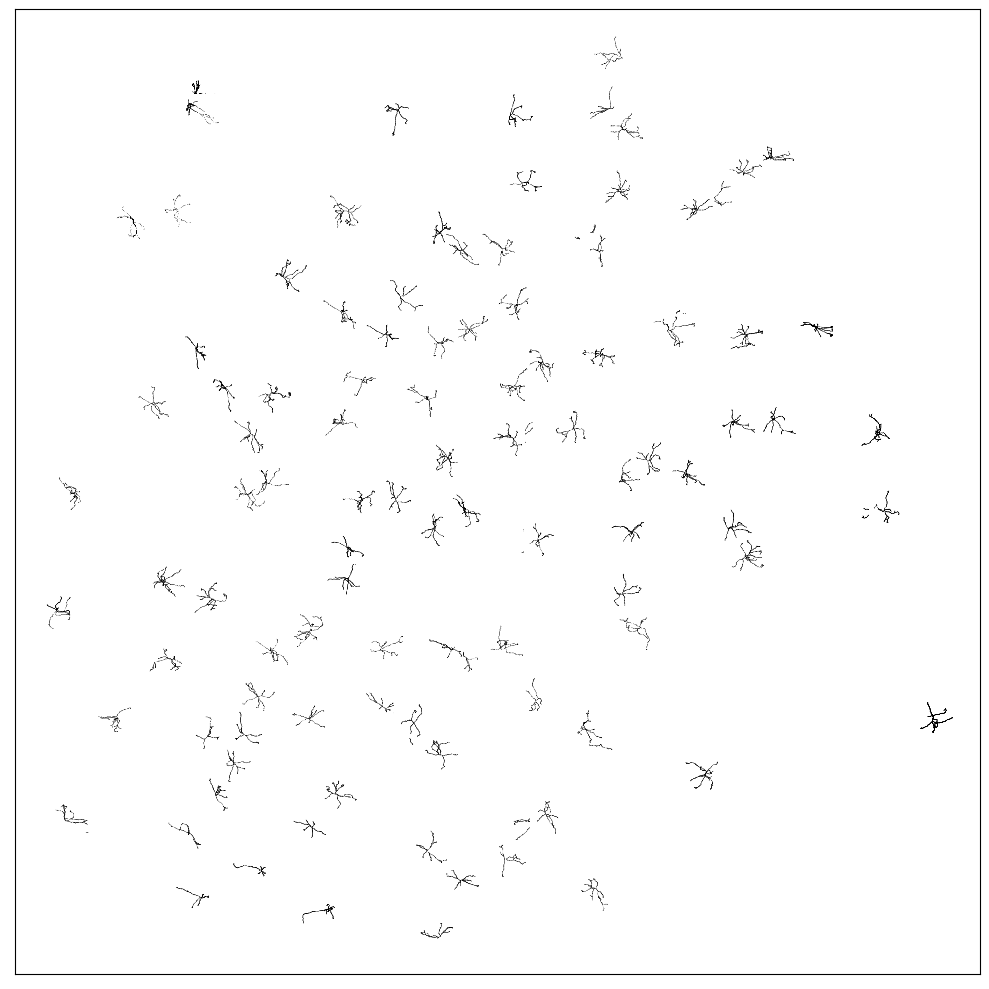

In [ ]:

# Use the already calculated embedding from earlier cell
# instead of recalculating it
n = 20
fig = create_morphology_scatter_plot(embedding, morphos, files, mv.plot_morphology_zy)
plt.show()

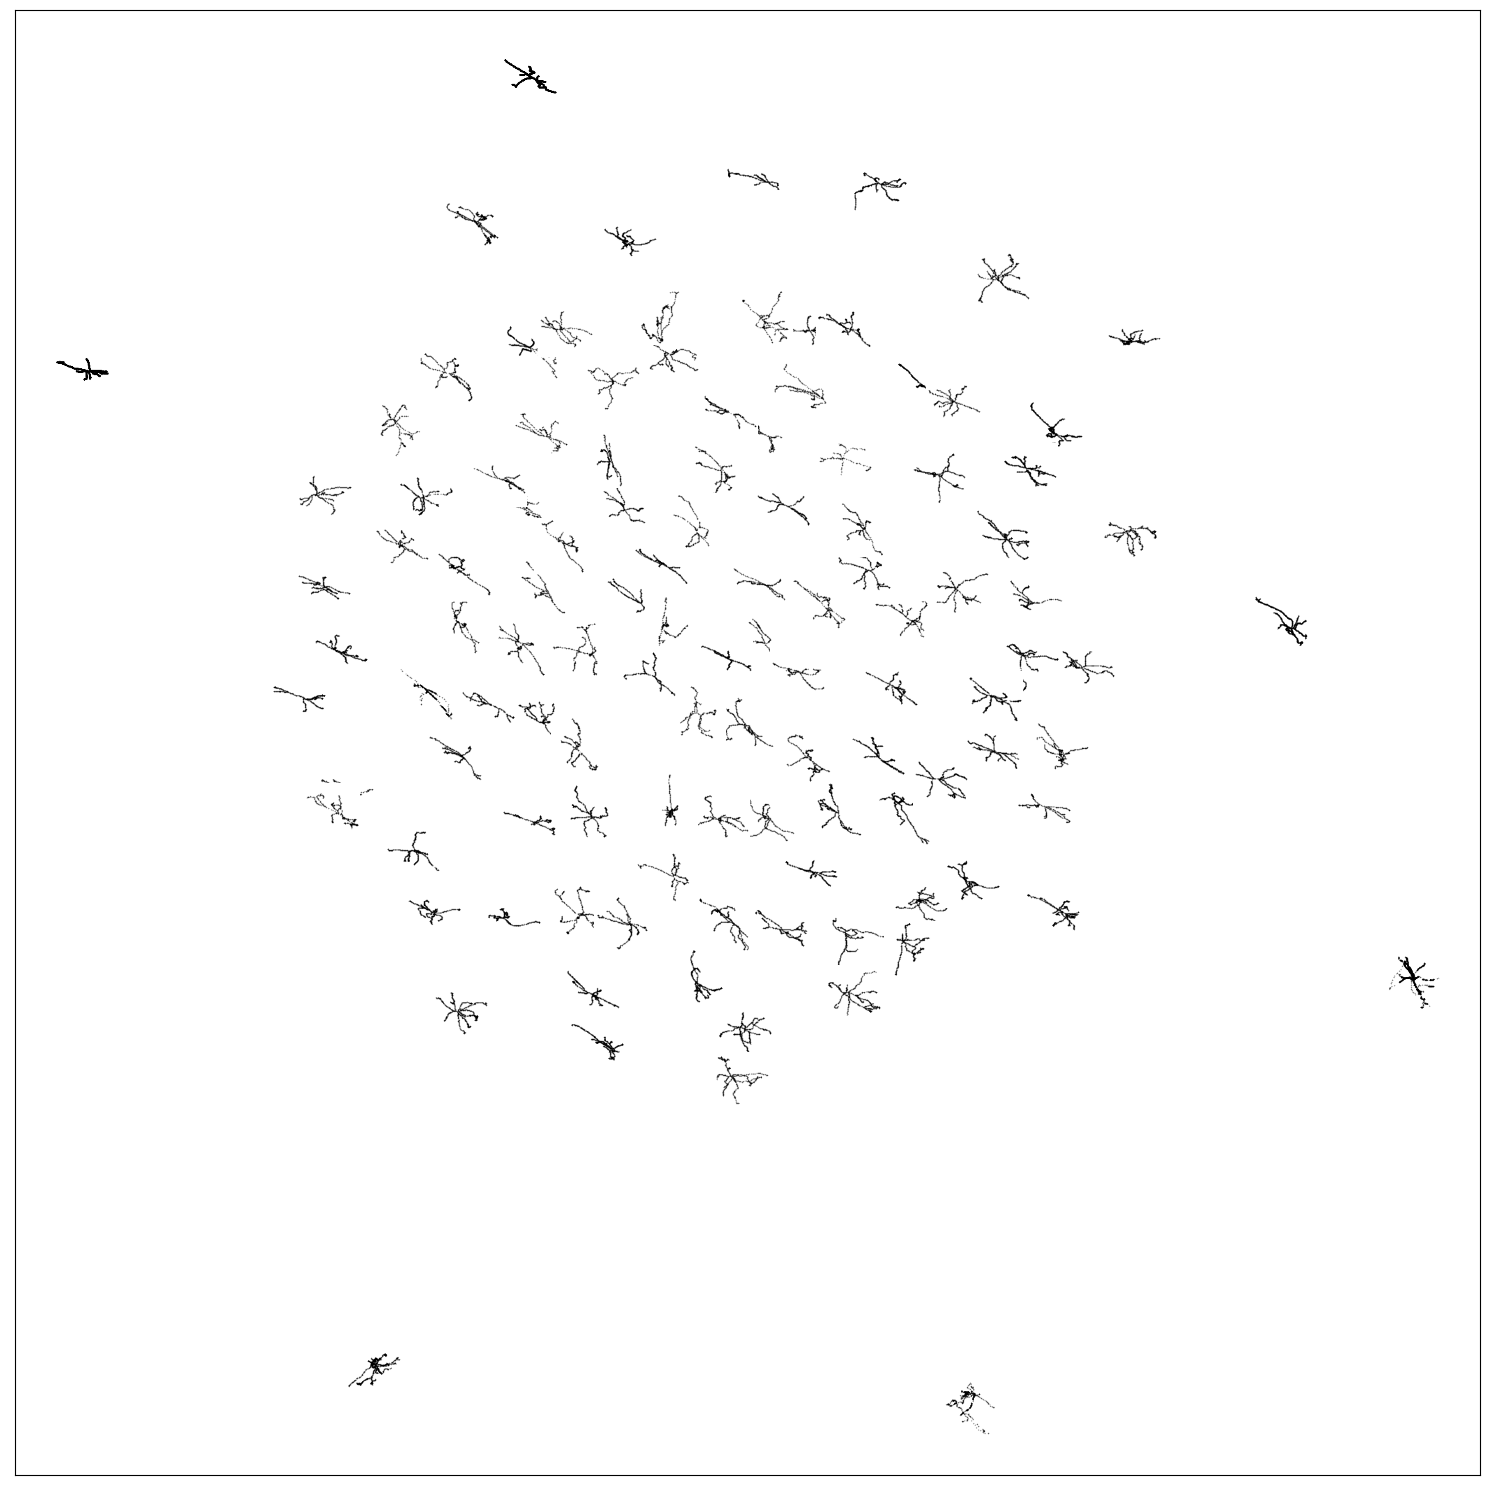

In [ ]:

fig = create_morphology_scatter_plot(embedding, morphos, files, mv.plot_morphology_xy)
plt.show()

## normalized MDS

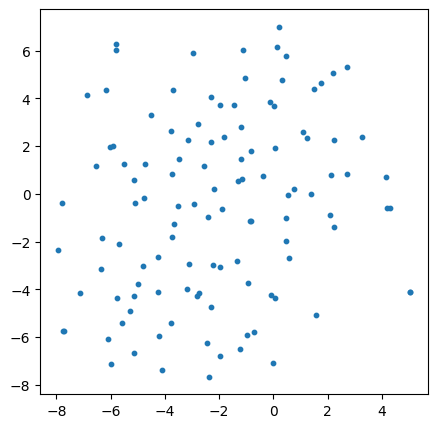

In [ ]:
embedding = model.fit_transform(norm_distance_matrix_np)

plt.figure(figsize=(5, 5))
plt.scatter(embedding[:, 0], embedding[:, 1], s=10)

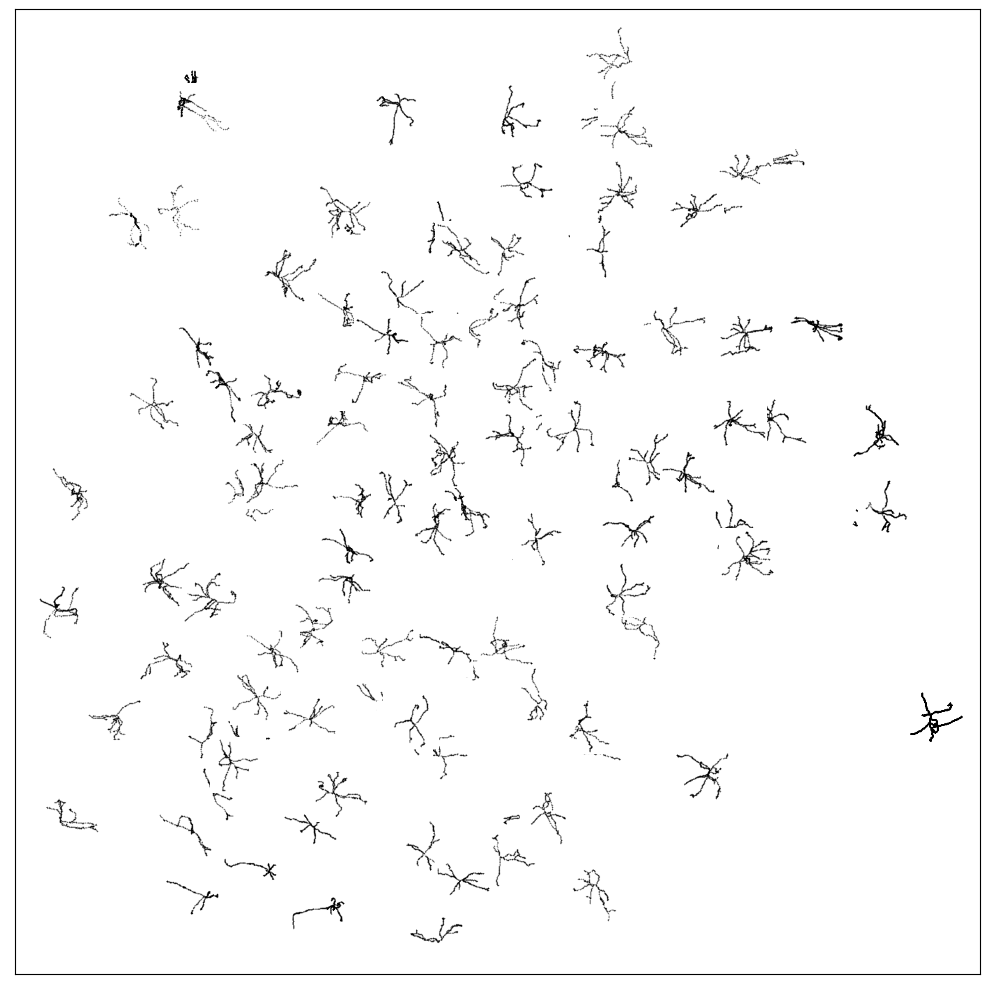

In [ ]:

# Use the already calculated embedding from earlier cell
# instead of recalculating it
n = 20
fig = create_morphology_scatter_plot(embedding, morphos, files, mv.plot_morphology_zy)
plt.show()

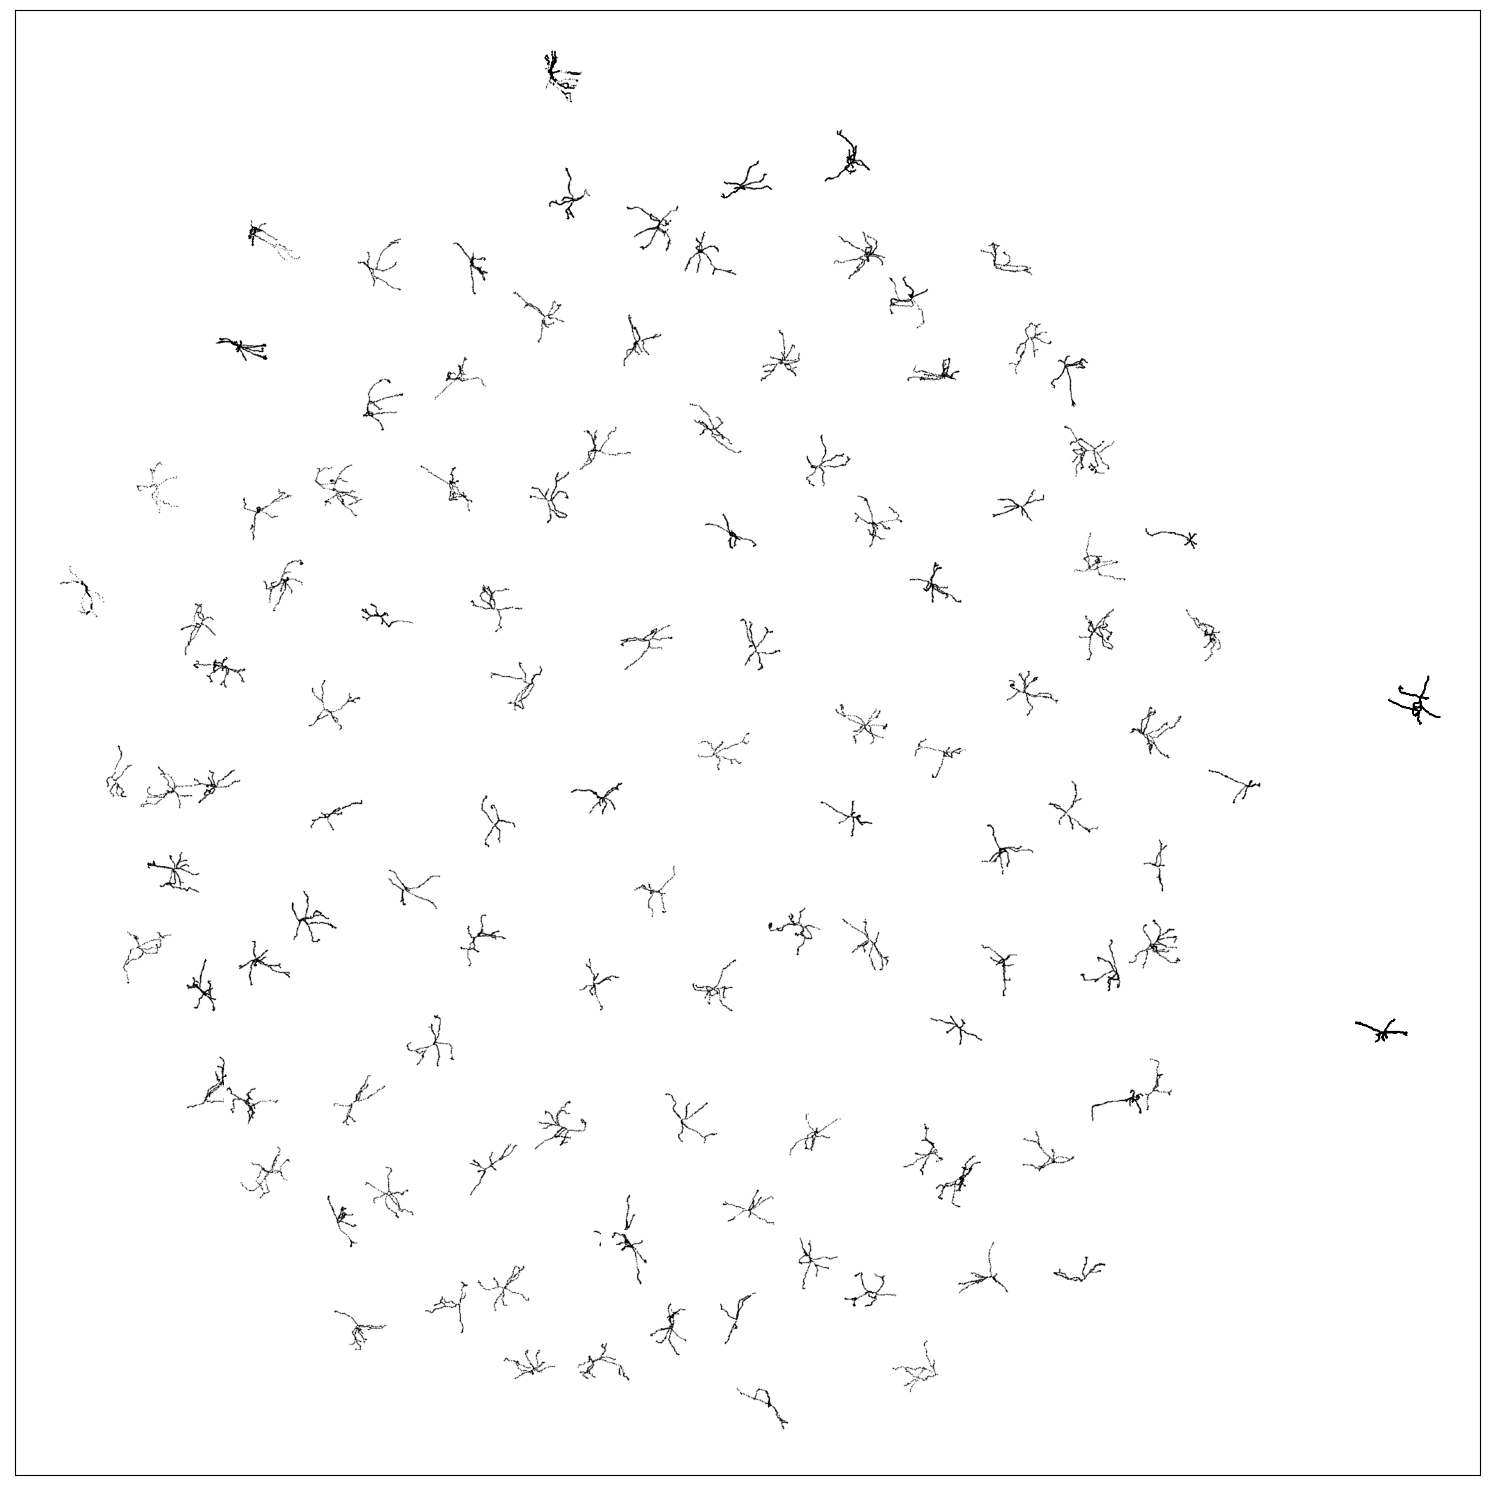

In [ ]:

# Use the already calculated embedding from earlier cell
# instead of recalculating it
n = 20
fig = create_morphology_scatter_plot(embedding, morphos, files, mv.plot_morphology_zy)
plt.show()

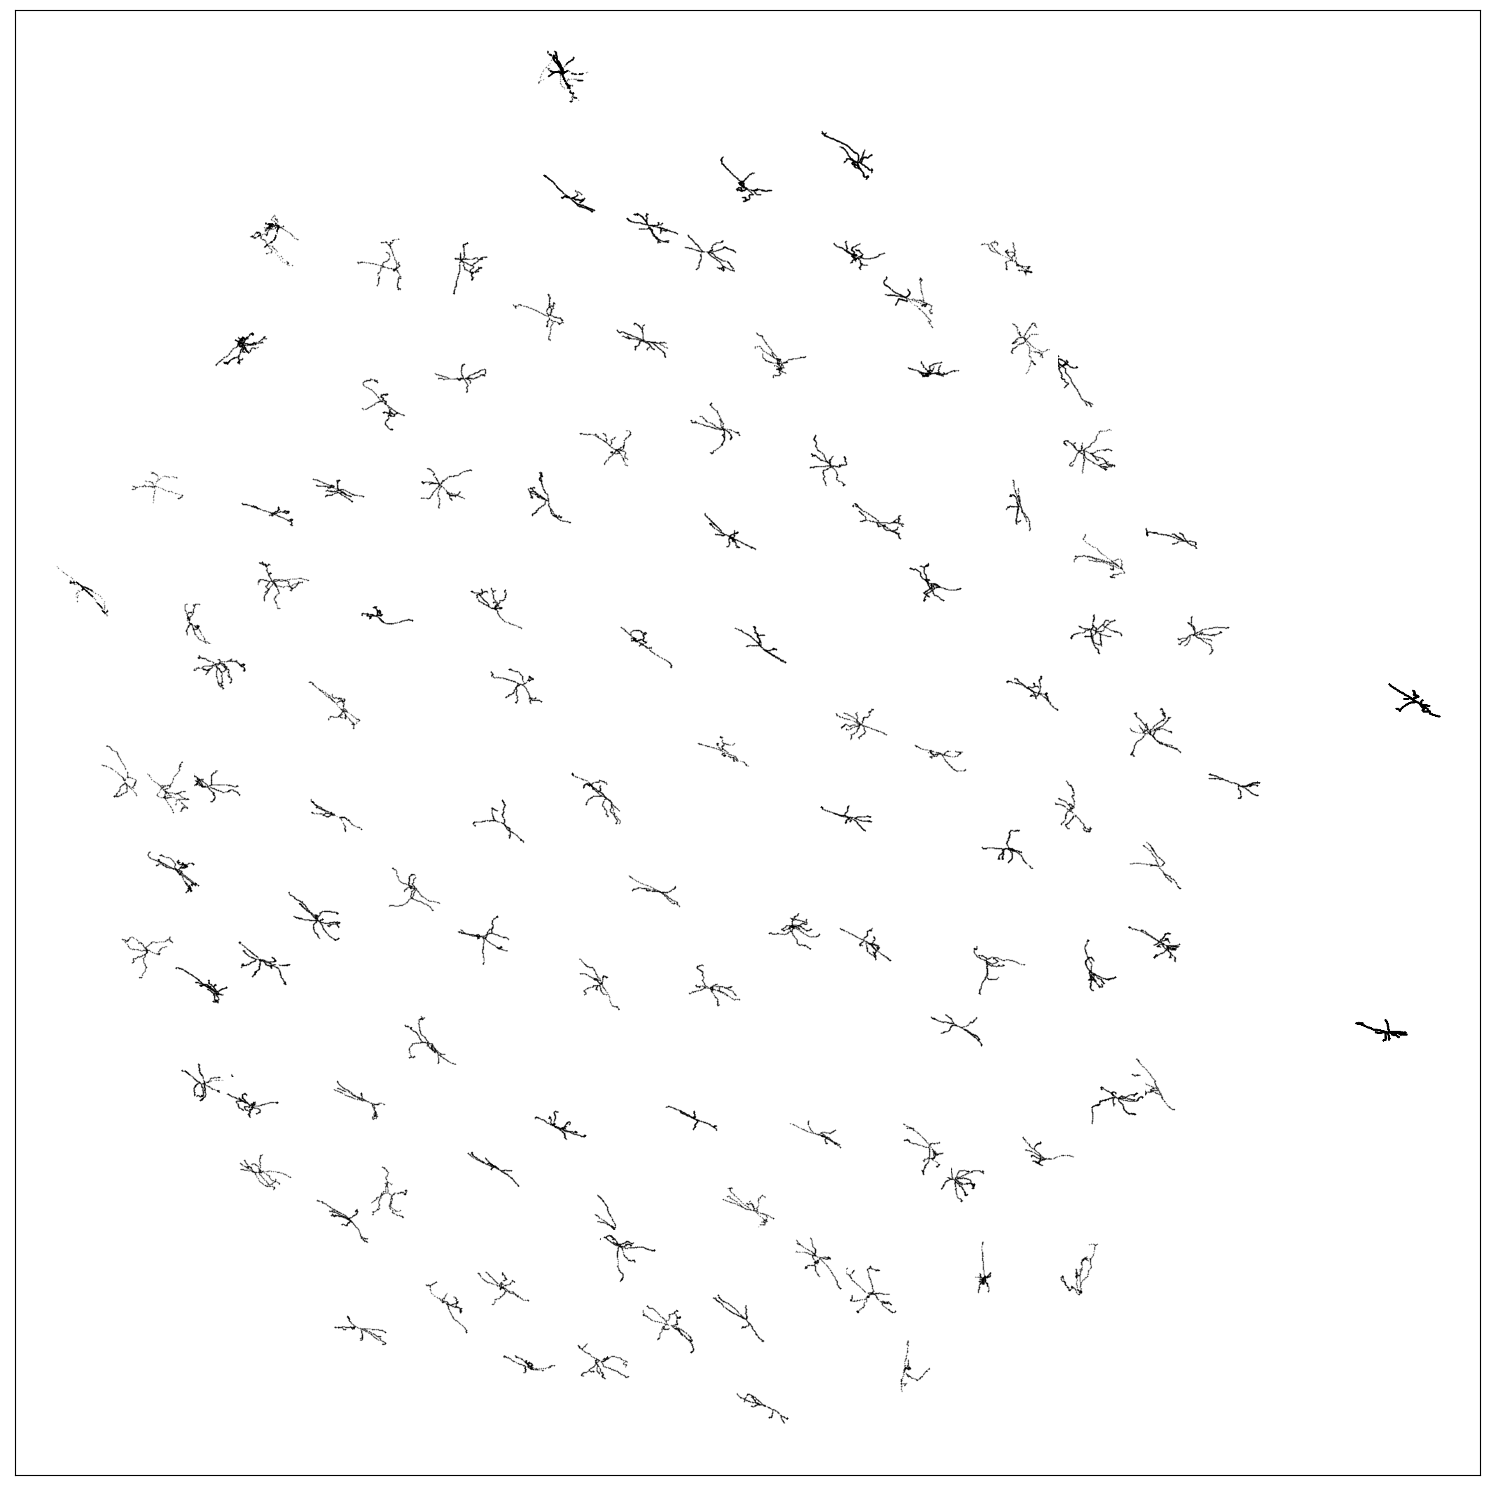

In [ ]:

fig = create_morphology_scatter_plot(embedding, morphos, files, mv.plot_morphology_xy)
plt.show()

## unnormalized TSNE

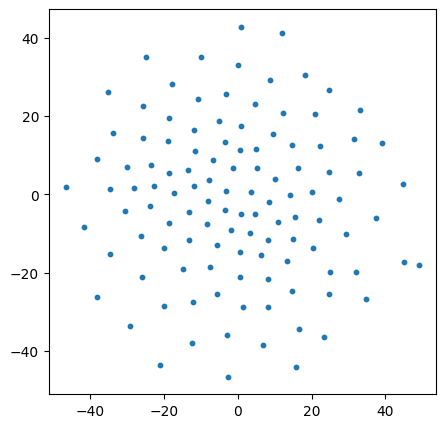

In [ ]:
model = manifold.TSNE(n_components=2, metric="precomputed", init="random", random_state=42)
embedding = model.fit_transform(distance_matrix_np)

plt.figure(figsize=(5, 5))
plt.scatter(embedding[:, 0], embedding[:, 1], s=10)

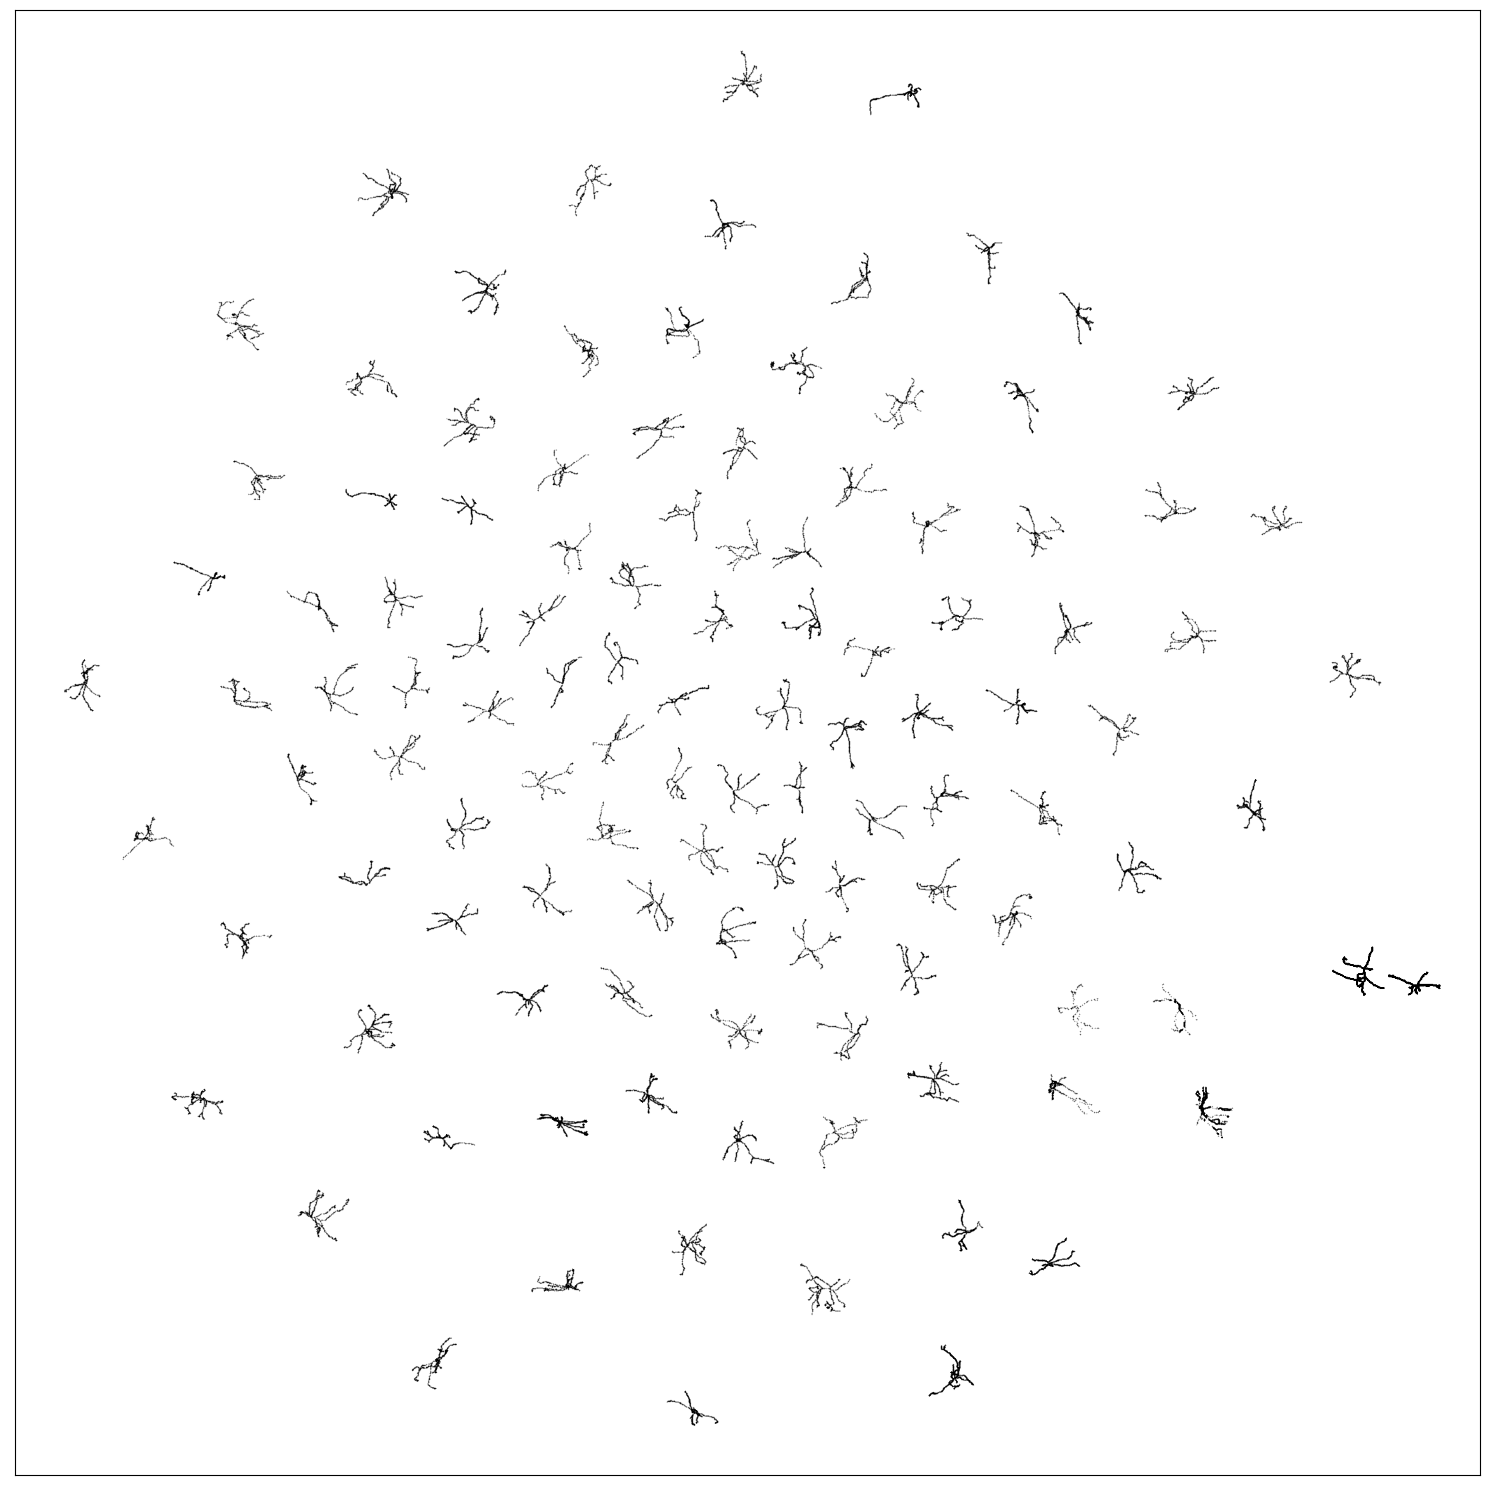

In [ ]:

# Use the already calculated embedding from earlier cell
# instead of recalculating it
n = 20
fig = create_morphology_scatter_plot(embedding, morphos, files, mv.plot_morphology_zy)
plt.show()

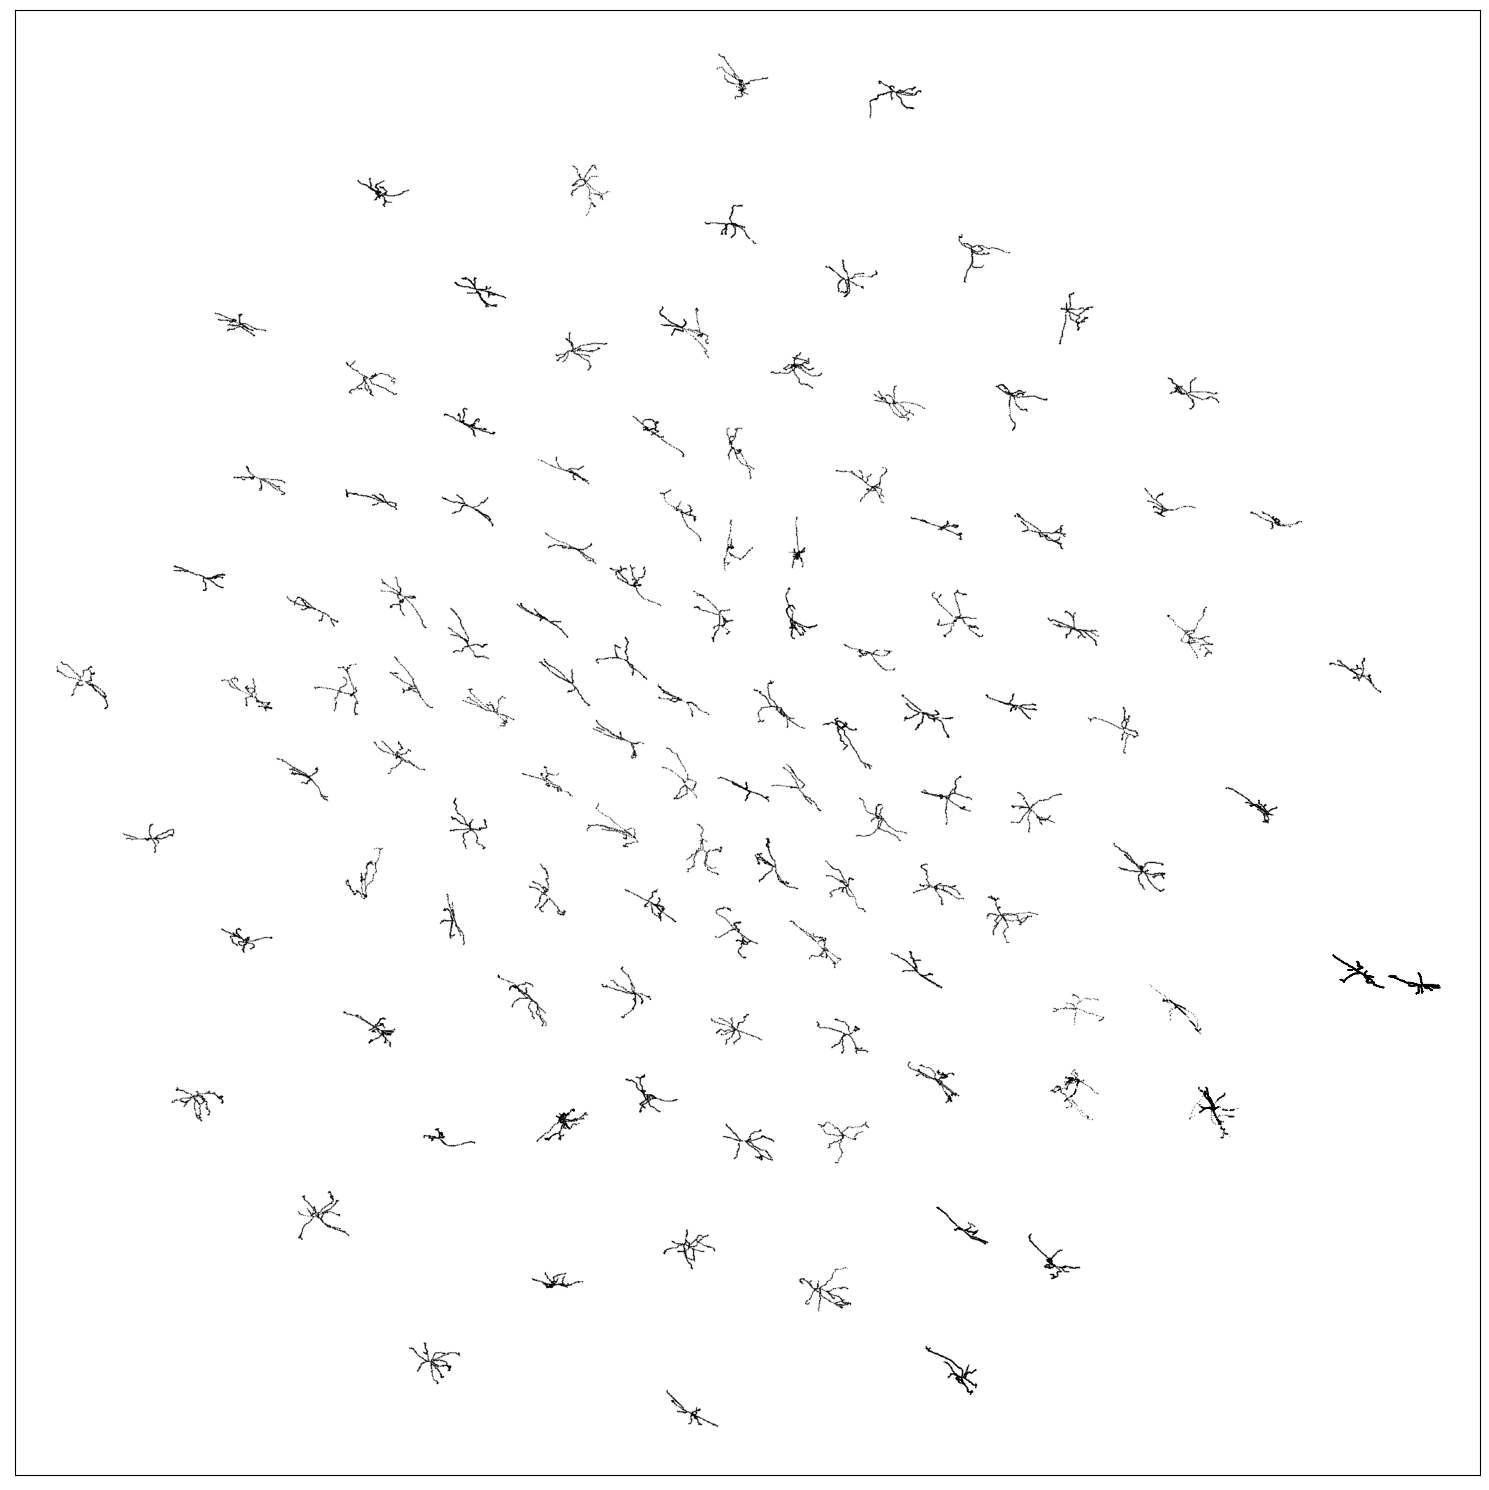

In [ ]:

fig = create_morphology_scatter_plot(embedding, morphos, files, mv.plot_morphology_xy)
plt.show()

In [ ]:
 Dendrites relationship to edges
 - direction correlation with surface normalize?
 - magnitude of dendrite CoM anticorrelated with distance to surface?